In [15]:
import pandas as pd

df = pd.read_csv("data/raw/D09 - winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 📊 Data Visualization

Sử dụng biểu đồ để phân tích phân bố và mối quan hệ giữa các thuộc tính.

### 📈 Phân bố chất lượng rượu

Biểu đồ histogram giúp quan sát số lượng mẫu theo từng mức chất lượng.

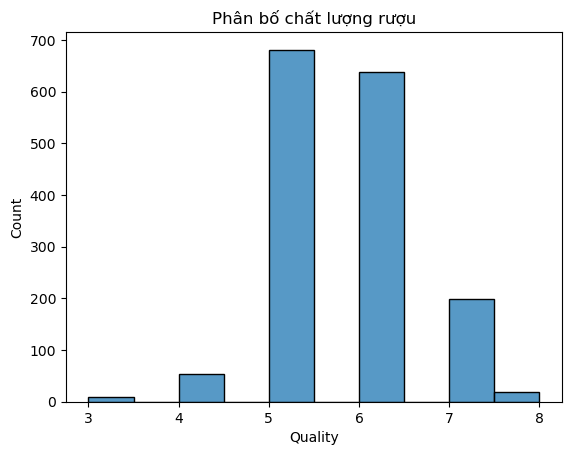

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
#Histogram
sns.histplot(df['quality'], bins=10)
plt.title("Phân bố chất lượng rượu")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

### 🔥 Ma trận tương quan

Heatmap thể hiện mối quan hệ giữa các thuộc tính trong dữ liệu.

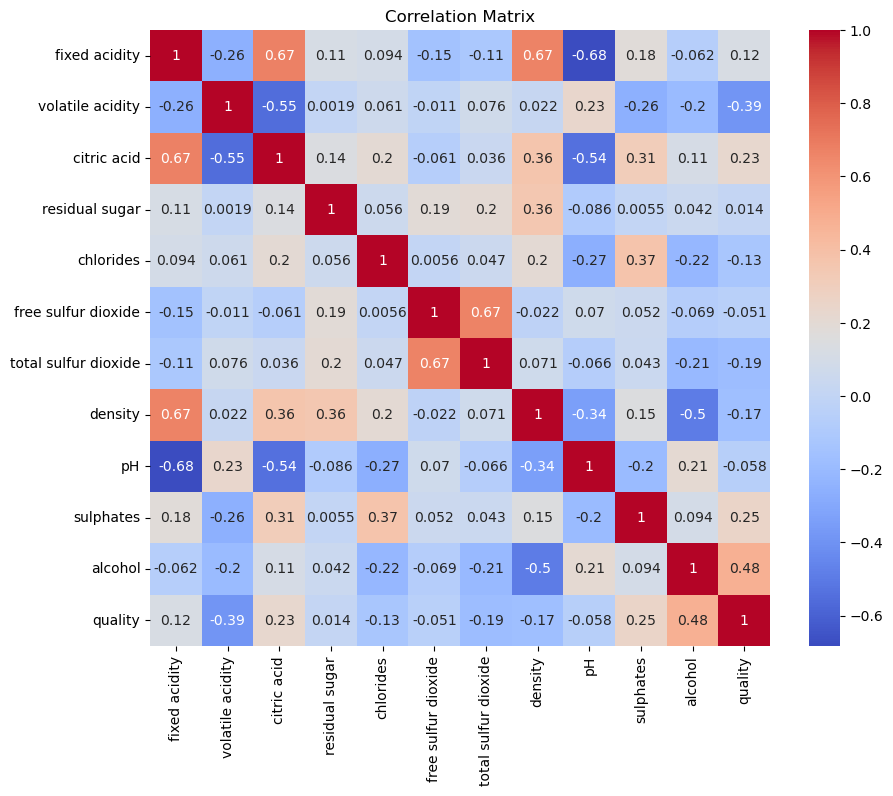

In [17]:
#Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### 📦 Alcohol vs Quality

So sánh nồng độ cồn theo từng mức chất lượng.

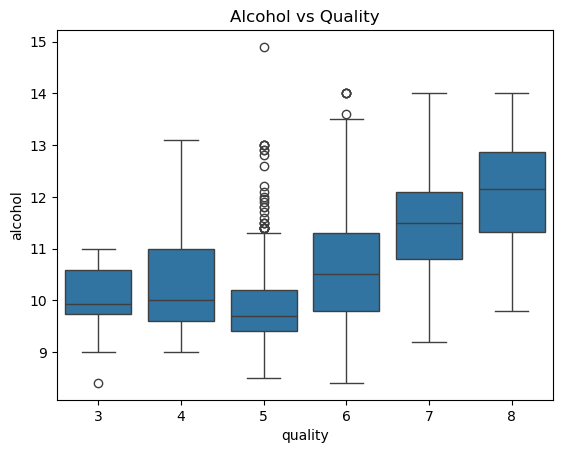

In [18]:
#Boxplot
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title("Alcohol vs Quality")
plt.show()

## 🤖 K-Means Clustering

K-Means là thuật toán học không giám sát dùng để phân cụm dữ liệu thành các nhóm dựa trên sự tương đồng.

### ⚙️ Chuẩn hóa dữ liệu

Dữ liệu được chuẩn hóa để đảm bảo các thuộc tính có cùng thang đo.

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

### 🧠 Áp dụng thuật toán K-Means

In [20]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


### 📊 Xem kết quả phân cụm

Hiển thị một số dòng dữ liệu để kiểm tra mỗi mẫu thuộc cụm nào.

In [21]:
df[['quality', 'cluster']].head()

,quality,cluster
0,5,0
1,5,0
2,5,0
3,6,2
4,5,0


### 🎨 Trực quan hóa kết quả phân cụm

Biểu đồ scatter giúp hiển thị các cụm dữ liệu dựa trên alcohol và quality, với mỗi màu đại diện cho một cụm khác nhau.

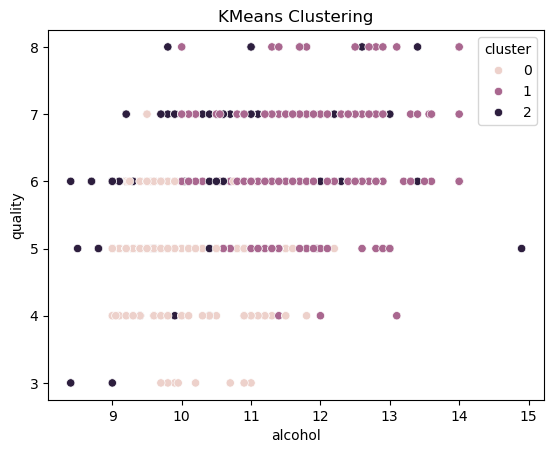

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df['alcohol'], y=df['quality'], hue=df['cluster'])
plt.title("KMeans Clustering")
plt.show()

### 🎨 Trực quan hóa cụm theo sulphates và alcohol

Biểu đồ scatter giúp quan sát sự phân bố các cụm dựa trên hai thuộc tính sulphates và alcohol, từ đó đánh giá mức độ tách biệt giữa các cụm.

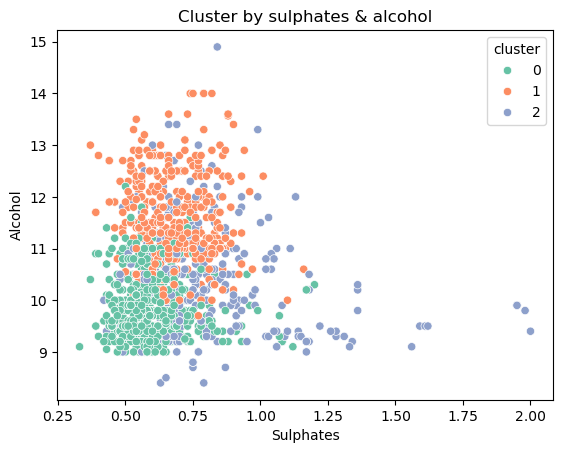

In [23]:
sns.scatterplot(
    x=df['sulphates'],
    y=df['alcohol'],
    hue=df['cluster'],
    palette='Set2'
)
plt.title("Cluster by sulphates & alcohol")
plt.xlabel("Sulphates")
plt.ylabel("Alcohol")
plt.show()

### 📊 Phân bố số lượng các cụm

Thống kê số lượng dữ liệu trong từng cụm để đánh giá sự phân bố giữa các nhóm.

<Axes: title={'center': 'Cluster Distribution'}, xlabel='cluster'>

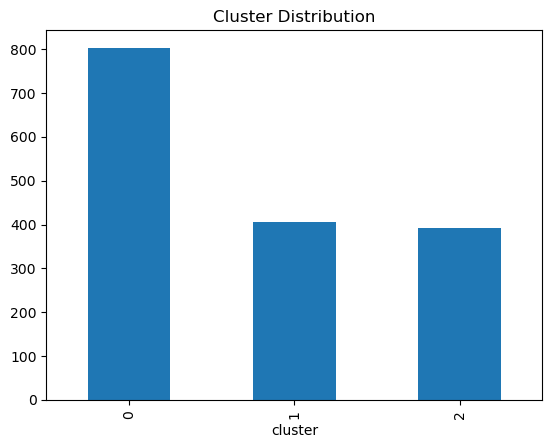

In [24]:
df['cluster'].value_counts().plot(kind='bar', title="Cluster Distribution")

### 📊 Phân tích đặc trưng của từng cụm

In [25]:
df.groupby('cluster').mean()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
cluster,,,,,,,,,,,,
0,7.731258,0.619166,0.174296,2.483375,0.085093,16.897260,54.816936,0.996935,3.341046,0.592715,9.822873,5.200498
1,7.372346,0.451568,0.247951,2.292840,0.070491,17.112346,39.066667,0.994762,3.387185,0.675235,11.620041,6.261728
2,10.509207,0.419207,0.493376,2.907417,0.109923,12.493606,36.987212,0.998416,3.170844,0.774834,10.415516,5.882353


### 🔬 Trực quan hóa phân cụm bằng PCA

Sử dụng PCA để giảm số chiều dữ liệu xuống 2 chiều nhằm trực quan hóa kết quả phân cụm K-Means một cách rõ ràng hơn.

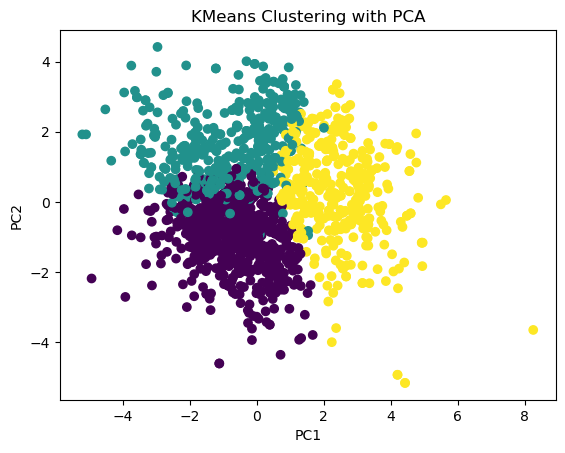

In [26]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# giảm chiều còn 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# vẽ
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])
plt.title("KMeans Clustering with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 🧠 Nhận xét

- Dữ liệu tập trung chủ yếu ở mức chất lượng trung bình
- Các cụm có sự khác biệt về alcohol, sulphates và acidity
- Một số cụm có xu hướng chất lượng cao hơn
- Các cụm chưa tách biệt hoàn toàn do dữ liệu chồng lấn

## 🏁 Kết luận

K-Means giúp phân nhóm dữ liệu thành các cụm có đặc điểm tương đồng.

Tuy nhiên, do dữ liệu có sự chồng lấn nên kết quả phân cụm chưa hoàn toàn rõ ràng.